In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyspedas
from pyspedas import tplot, get_data
import pandas as pd
import os
import datetime
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import scipy.io as sio
from scipy.io import readsav

05-Oct-26 15:44:57: /opt/anaconda3/lib/python3.13/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()



In [2]:
from pyspedas import tplot, get_data
from scipy.interpolate import interpn 
import numpy.ma as ma

In [3]:
"""
This function downloads optical data from pySPEDAS database in 6300 and 5725
input: start_date = start date for optical data (Type:str), in the form of 'year-month-day'
       end_date = end date for optical data (Type:str), in the form of 'year-month-day'
       station = rsb or eur (Type: str)
output: Opt_Bkg_data = 3D array with background data: 
        Opt_Bkg_time = 1D array of background time
        Opt_img_data = 3D array with image data
        Opt_img_time = 1D array of image times
"""

def Optical_data_download(start_date, end_date, station):
    # download background data from pySPEDAS database
    background = pyspedas.projects.erg.camera_omti_asi(trange=[start_date, end_date], site=station, wavelength = 5725)
    background_data = get_data(background[2], dt = True)
    Opt_Bkg_data = background_data.y
    Opt_Bkg_time = background_data.times.astype('datetime64[s]')
    
    # download raw image data from pySPEDAS database
    raw_image = pyspedas.projects.erg.camera_omti_asi(trange=[start_date, end_date], site=station, wavelength = 6300)
    raw_image_data = get_data(raw_image[2], dt = True)
    Opt_img_data = raw_image_data.y
    Opt_img_time = raw_image_data.times.astype('datetime64[s]')

    return Opt_Bkg_data, Opt_Bkg_time, Opt_img_data, Opt_img_time 

In [4]:
raw_optical_data = Optical_data_download('2014-02-22/07:00', '2014-02-22/09:00', 'rsb') # insert input5
#print(optical_data)

# define variables for each output of radar_data_process
bkg_counts = raw_optical_data[0]
bkg_times = raw_optical_data[1]
raw_img_counts = raw_optical_data[2]
raw_img_times = raw_optical_data[3]

05-Oct-26 15:44:57: Downloading remote index: https://ergsc.isee.nagoya-u.ac.jp/data/ergsc/ground/camera/omti/asi/rsb/2014/02/22/
05-Oct-26 15:45:22: Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ReadTimeoutError("HTTPSConnectionPool(host='ergsc.isee.nagoya-u.ac.jp', port=443): Read timed out. (read timeout=20)")': /data/ergsc/ground/camera/omti/asi/rsb/2014/02/22/
05-Oct-26 15:45:47: Retrying (Retry(total=1, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ReadTimeoutError("HTTPSConnectionPool(host='ergsc.isee.nagoya-u.ac.jp', port=443): Read timed out. (read timeout=20)")': /data/ergsc/ground/camera/omti/asi/rsb/2014/02/22/


KeyboardInterrupt: 

In [ ]:
"""
This function downloads correct calibration files and then converts brightness counts to rayleighs 
input: #path_5577 = path to .txt file that contains array of pixel intensities for 557.7 nm # hardcoded in as same for rsb and eur
       path_5725 = path to calibration .txt file that contains array of pixel intensities for 572.5 nm, transmission, bandwidth, and wl 
       path_6300 = path to calibration .txt file that contains array of pixel intensities for 630.0 nm, transmission, bandwidth, and wl 
       Bkg_5725 = bkg_counts: 3D array of background counts [time,lat,lon]
       data_6300 = raw_img_counts: 3D array of image counts [time,lat,lon]
    
output: all constants, plus data calibration and background calibration arrays and interpolated backgound array
Note: this will depend on the resolution of your image, ie (256x256) or (512x512) resolutions for EUR and RSB are hard coded in. 
"""

def optical_calibrate(calib_path_5725, calib_path_6300, Bkg_5725, data_6300): 
    # download the calibration text files 
    bkg_calibration_file =  open(calib_path_5725, "r")
    bkg_Calib_data = bkg_calibration_file.readlines()

    img_calibration_file = open(calib_path_5725, "r")
    img_Calib_data = img_calibration_file.readlines()
    
    # Background wl, bandwidth, transmission, and sensitivity array
    # strip extra white spaces and put into a list
    bkg_list = []
    for line in bkg_Calib_data:
        lne = line.strip()
        bkg_list.append(lne) # strip extra white spaces  
    bkg_list

    # extract all the information 
    bkg_meta_data = bkg_list[0]
    bkg_sensitivity_list = bkg_list[1:-1]

    # convert bkg_sensitivity_list to bkg_sensitivity array
    bkg_sensitivity = []
    for i in range(len(bkg_sensitivity_list)):
        sens_elements = bkg_sensitivity_list[i].split()
        bkg_sensitivity.append(sens_elements) # split by line 

    # convert to array of floats and define constants
    bkg_wl = float(bkg_sensitivity[0][0])
    bkg_bandwidth = float(bkg_sensitivity[0][1])
    bkg_transmission = float(bkg_sensitivity[0][2])
    bkg_sensitivity_array = np.array(bkg_sensitivity[1:-1]).astype(float)

    # Image wl, bandwidth, transmission, and sensitivity array
    # strip extra white spaces and put into a list
    img_list = []
    for line in img_Calib_data:
        lne = line.strip()
        img_list.append(lne) # strip extra white spaces  

    # extract all the information 
    img_meta_data = img_list[0]
    img_sensitivity_list = img_list[1:-1]

    # convert bkg_sensitivity_list to bkg_sensitivity array
    img_sensitivity = []
    for i in range(len(img_sensitivity_list)):
        sens_elements = img_sensitivity_list[i].split()
        img_sensitivity.append(sens_elements) # split by line 

    # convert to array of floats
    img_wl = float(img_sensitivity[0][0])
    img_bandwidth = float(img_sensitivity[0][1])
    img_transmission = float(img_sensitivity[0][2])
    img_sensitivity_array = np.array(img_sensitivity[1:-1]).astype(float)
    print(img_sensitivity_array.shape)

    # get the sensitivity arrays- idl translation via chat gpt
    # Step 2: Flatten it
    img_flat_data = img_sensitivity_array.flatten()  # shape: (262136,)
    bkg_flat_data = bkg_sensitivity_array.flatten()

    # Step 3: Trim or pad img data to 262144 (512x512) or (1024, 1024)
    target_size = 512 * 512 # size of image is either 512x512 or 256x256, if the size of the image is 256x256, then target_size should be 512x512
    if img_flat_data.size > target_size:
        img_flat_data = img_flat_data[:target_size]
    elif img_flat_data.size < target_size:
        img_flat_data = np.pad(img_flat_data, (0, target_size - img_flat_data.size))

    # Step 3: Trim or pad bkg data to 262144 (512x512)
    if bkg_flat_data.size > target_size:
        bkg_flat_data = bkg_flat_data[:target_size]
    elif bkg_flat_data.size < target_size:
        bkg_flat_data = np.pad(bkg_flat_data, (0, target_size - bkg_flat_data.size))

    # Step 4: Reshape into 512×512
    cal_ag0 = img_flat_data.reshape((512, 512))  # for airglow, (512, 512) for a 256x256 image
    cal_bg0 = bkg_flat_data.reshape((512, 512))  # for background, (512, 512) for 256x256 image

    plt.imshow(np.transpose(cal_ag0), cmap = 'grey', aspect = 'auto', norm = 'log')
    plt.imshow(np.transpose(cal_bg0), cmap = 'grey', aspect = 'auto', norm = 'log')
    

    # Step 5: Set final width (after binning)
    wid0 = 512              # original width, also 2x2 binning for the 512, so then 1024, for 256 should be 512
    wid_cdf = 256           # width of data- set 256 or 512 depending 
    binning_factor = wid0 // wid_cdf

    # Step 6: Allocate new arrays
    cal_ag = np.zeros((wid_cdf, wid_cdf))
    cal_bg = np.zeros((wid_cdf, wid_cdf))

    # Step 7: Apply binning
    if wid_cdf == wid0:
        cal_ag = cal_ag0.copy()
        cal_bg = cal_bg0.copy()
    elif binning_factor == 2:
        for j in range(wid_cdf):
            for i in range(wid_cdf):
                cal_ag[j, i] = (
                    cal_ag0[j*2, i*2] + cal_ag0[j*2, i*2+1] +
                    cal_ag0[j*2+1, i*2] + cal_ag0[j*2+1, i*2+1]
                ) / 4.0
                cal_bg[j, i] = (
                    cal_bg0[j*2, i*2] + cal_bg0[j*2, i*2+1] +
                    cal_bg0[j*2+1, i*2] + cal_bg0[j*2+1, i*2+1]
                ) / 4.0
    elif binning_factor == 4:
        for j in range(wid_cdf):
            for i in range(wid_cdf):
                cal_ag[j, i] = np.sum(cal_ag0[j*4:j*4+4, i*4:i*4+4]) / 16.0
                cal_bg[j, i] = np.sum(cal_bg0[j*4:j*4+4, i*4:i*4+4]) / 16.0

    # time series interpolate background data  
    # define length of time for data and for background
    bkg_time_len = len(Bkg_5725[:, 0, 0])
    data_time_len = len(data_6300[:, 0, 0])
    data_wid = len(data_6300[0, :, 0])
    
    time_orig = np.linspace(0, bkg_time_len-1 , bkg_time_len)        # shape: (len(bkg_times),)
    lat_orig = np.linspace(0, data_wid-1, data_wid)       # shape: (len(bkg_counts[0, 0, :]),)
    lon_orig = np.linspace(0, data_wid-1, data_wid)       # shape: (len(bkg_counts[0, 0, :]),)

    points = (time_orig, lat_orig, lon_orig) # is a tuple the shape of all the axes 

    # Target interpolation grid: # time steps in raw image 6300 file
    time_interp = np.linspace(0, bkg_time_len-1, data_time_len) # shape: (len(raw_img_times),)

    # Generate full coordinate grid for xi
    T, Y, X = np.meshgrid(time_interp, lat_orig, lon_orig, indexing='ij')  # shape: (330, 256, 256)

    # Stack into xi points
    xi = np.stack([T, Y, X], axis=-1).reshape(-1, 3)  # shape: (330*256*256, 3)

    # Interpolate
    bkg_interp = interpn(points, bkg_counts, xi, method='linear', bounds_error=False, fill_value=np.nan)
    bkgInterp_array = bkg_interp.reshape((data_time_len, data_wid, data_wid)) # shape: (len(raw_img_times), len(raw_img_counts[0, :, 0]), len(raw_img_counts[0, 0, :]))

    return bkg_bandwidth, bkg_transmission, img_bandwidth, img_transmission, cal_ag, cal_bg, bkgInterp_array

(65534, 4)


11-May-26 16:06:36: /var/folders/9s/z2lw0gwj5zb4mbfb2l8c3vvw0000gp/T/ipykernel_59363/3990245849.py:1: ResourceWarning: unclosed file <_io.TextIOWrapper name='/Users/ameliale/Test_folder/RSB_Background_calibration_M6C50002 copy.txt' mode='r' encoding='UTF-8'>
  calibration = optical_calibrate("/Users/ameliale/Test_folder/RSB_Background_calibration_M6C50002 copy.txt",



<function optical_calibrate at 0x1056a2520>


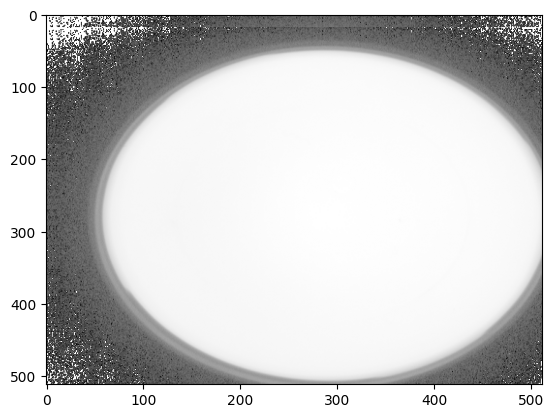

In [ ]:
# insert paths to calibration files and background and raw image data from optical data dowload file, download calibration files from here: https://stdb2.isee.nagoya-u.ac.jp/omti/stations.html#calibration  
calibration = optical_calibrate("path_to_bkg_cal_file", "path_to_wl_cal_file", bkg_counts, raw_img_counts) # insert inputs
print(optical_calibrate)

# define variables for each output of radar_data_process
dFb = calibration[0]
Transmission_bkg = calibration[1]
dFa = calibration[2]
Transmission_img = calibration[3]
calibration_6300 = calibration[4]
calibration_5725 = calibration[5]
bkg_inp_array = calibration[6]

## Function to convert counts to rayleighs 

In [ ]:
# equations to convert counts to rayleighs:
# background intensity
def I_b(Nb, Dkb, Transmissionb, Ab, ta, dfb):
    #Ab = ab*Transmission
    Ib = ((Nb-Dkb)*Transmissionb)/(Ab*ta*dfb) # (mod_bg - dc_bg) * tlb / (cal_bg * exp_bg * dfb)
    return Ib

In [ ]:
# counts to rayelighs  
def I_a(Na, Dka, Transmissiona, Aa, ta, dfa, Ib):
    #Aa = aa * Transmission
    Ia = (Na-(Aa*ta*Ib*dfa/Transmissiona)-Dka)/(Aa*ta) # ag_int = (img_ag - cal_ag * exp_ag * bg_int * dfa / tla - dc_ag) / (cal_ag * exp_ag)
    return Ia

In [ ]:
def get_rayeligh_arrays(Nb, Dkb, Transmissionb, Ab, tb, dFb, Na, Dka, Transmissiona, Aa, ta, dFa):
    Ib = I_b(Nb, Dkb, Transmissionb, Ab, tb, dFb)
    Ia = I_a(Na, Dka, Transmissiona, Aa, ta, dFa, Ib)
    print(Ia.shape)
    return Ia   

In [ ]:
Optical_data = get_rayeligh_arrays(bkg_inp_array.astype(int), int(min(bkg_counts[0,:,0])), Transmission_bkg, calibration_5725, 30,
                                   dFb, raw_img_counts.astype(int), int(min(raw_img_counts[0,:,0])), Transmission_img, calibration_6300, 30, dFa) # insert everything
Keogram_data = Optical_data
Keogram_data.shape

11-May-26 16:06:49: /var/folders/9s/z2lw0gwj5zb4mbfb2l8c3vvw0000gp/T/ipykernel_59363/3285498751.py:5: RuntimeWarning: divide by zero encountered in divide
  Ib = ((Nb-Dkb)*Transmissionb)/(Ab*ta*dfb) # (mod_bg - dc_bg) * tlb / (cal_bg * exp_bg * dfb)

11-May-26 16:06:49: /var/folders/9s/z2lw0gwj5zb4mbfb2l8c3vvw0000gp/T/ipykernel_59363/3285498751.py:5: RuntimeWarning: invalid value encountered in divide
  Ib = ((Nb-Dkb)*Transmissionb)/(Ab*ta*dfb) # (mod_bg - dc_bg) * tlb / (cal_bg * exp_bg * dfb)

11-May-26 16:06:49: /var/folders/9s/z2lw0gwj5zb4mbfb2l8c3vvw0000gp/T/ipykernel_59363/1160090580.py:4: RuntimeWarning: invalid value encountered in multiply
  Ia = (Na-(Aa*ta*Ib*dfa/Transmissiona)-Dka)/(Aa*ta) # ag_int = (img_ag - cal_ag * exp_ag * bg_int * dfa / tla - dc_ag) / (cal_ag * exp_ag)



(60, 256, 256)


(60, 256, 256)

In [ ]:
"""
This function processes the optical data: background subtraction, SNR, and converts to keogram format ([time, latitude])
inputs: takes the time array [1]
        takes processed and converted keogram array (either two or three axies) you have to cut the array according to the latitude and longitude. easiest to do here (see comments below), will be different for different stations. 
Output: processed keogram array (2 axies) time and latitude.  
"""

def optical_data_process(keo_data, time_array):
    #background Subtract Data
    raw_keogram_array = keo_data[:, 0:221, 28:28+221]  #[:, 0:221, 28:28+221] for rsb data #[:, 30:457, 256] calibrated for EUR # this has the size of [time, lat_pixel], for EUR data [:, 75:415:, 256], for RSB data [:, 40:230, 128]
    # change according to site
    # first have to mask the top of the keogram basically from 0 to 28 (the very top, then can put through background)

    masked_array = ma.masked_array(raw_keogram_array)
    masked_array[:, 0:30, :] = ma.masked

    print('not masked:', raw_keogram_array[0,0:35,100])

    print('Not background subtracted but masked: ', masked_array[0, 0:35, 100])
   
    cmap18 = plt.get_cmap('plasma')
    plt.imshow(masked_array[:, :, 100].T, aspect = 'auto', norm = 'log', cmap = cmap18)
    cmap18.set_bad('black')

    plt.show()

    print("indexing ex: ", masked_array[0, :, 100])

    print('masked_array', masked_array[0:2, :, 100])
    print('masked array min', np.nanmin(masked_array[0:2, :, 100]))
    print('bkg sub example:', masked_array[0:2, :, 100] - np.ma.min(masked_array[0:2, :, 100]))


    bkgsub_list = []
    start_index = 0
    while start_index < len(time_array):  
        end_index = start_index + 2
        split_data = masked_array[start_index:end_index, : , 100] #raw_keogram_array for eureka omit third axis completly as it's already cut to the middle
        #print('split data min: ', split_data)# how to ignore the top part?
        bkg_sub_data = split_data - np.ma.min(split_data) #np.ma.min(split_data)# exclude nans from min split_data.min()
        bkgsub_list.append(bkg_sub_data)
        start_index = end_index

    print('bkg sub: ', bkgsub_list[0])

    data_array = np.asarray(bkgsub_list, dtype = float)

    print(data_array.shape)

    #print(data_array[60, 0:35, 128])

    image_data = data_array[0]
    for j in range(1, len(data_array)):
        image_data = np.concatenate((image_data, data_array[j]), axis = 0)

    print(image_data.shape)

    cmap11 = plt.get_cmap('plasma')
    plt.imshow(image_data[:, :].T, aspect = 'auto', norm = 'log', cmap = cmap11)
    cmap11.set_bad('black')

    print(image_data.shape)

    keogram_array = image_data # for now don't transpose until plotting.T # insert previously selceted time indices [120:327, :] for 2014-02-22 [75:194, :] for 2023-02-21
    #time_array = time_array

    print(keogram_array.shape)
    print(len(keogram_array[0, :]))

    # trying to make the snr larger
    '''new_list = []
    start_index = 0
    for i in range(0, int(len(keogram_array[0, :])/2)):
        end_index = start_index + 2
        #print(start_index, end_index)
        mean = np.mean(keogram_array[:, start_index:end_index], axis = 1) #print(start_index, end_index)
        new_list.append(mean)
        #print(end_index)
        start_index = end_index
    new_list.append(keogram_array[:, -1]) 
    print(len(new_list))
    #print(new_list)
    mean_array = np.array(new_list)
    averaged_data = mean_array.T'''
    #masked_keo_data = np.ma.masked_greater(keogram_array, 550)
    
    return time_array, keogram_array, raw_keogram_array, masked_array

not masked: [12391.57372986  4880.65999118   755.68654122 11896.43107068
 -2426.44828632 -1213.41341862   353.10734463 -2971.92591413
  1156.73799884   529.66101695  5617.26030895  7871.74306631
  -858.84828445  -726.5923726  -5617.26030895  4026.32597755
  -806.33549316  2519.28830105  5903.62334883  3084.63466358
  2347.22105793  2327.5591961   1208.24788159  -388.85648418
   153.55675842  1320.49518569  1734.51459759   971.22420186
  2303.35137625  1556.47605215   896.32621658   822.67186886
   843.20749518   818.17359037   851.02420857]
Not background subtracted but masked:  [-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- 896.3262165801117 822.6718688564257 843.207495177735
 818.1735903701691 851.0242085661079]


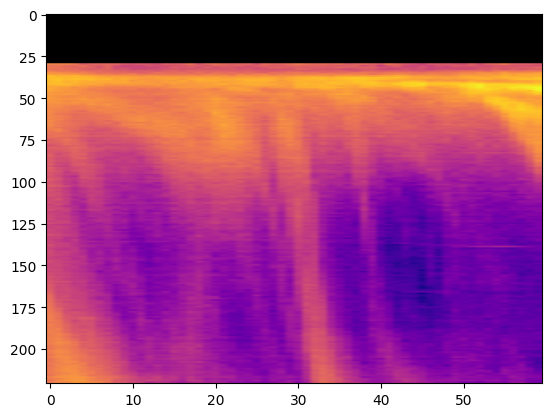

indexing ex:  [-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- -- -- -- 896.3262165801117 822.6718688564257 843.207495177735
 818.1735903701691 851.0242085661079 959.8201076986804 1003.9281705948373
 1166.7880946598666 1164.4013956152683 1174.0548984039403
 1147.3176479251813 1161.1991914468717 1144.1144114411443
 1080.2212501355698 1052.4532229564545 1081.5475334388034
 1047.3097557784042 987.3357228195937 1011.81249023637 972.5579411346508
 995.0459514479707 992.151004244623 977.3970973114441 970.0700235002207
 931.1547465481823 946.8362921967463 927.8682656166101 901.8908312522299
 927.0561920738598 920.445191997996 910.8616354428586 901.9481985997694
 917.6576704882622 899.3354723193578 931.9929606325788 895.4044051597139
 924.980096760365 896.516014498114 887.2008375331726 869.4084994413005
 835.9336704804945 812.5126955108674 814.4095173383877 798.9246160617632
 806.25624742753 726.3257908998135 746.3353803439918 746.8879668049793
 697.3987028384

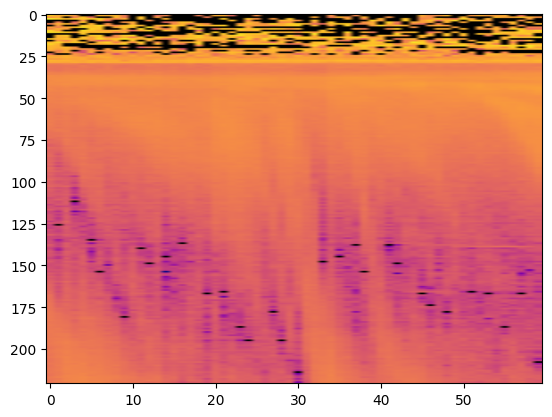

In [ ]:
Optical = optical_data_process(Keogram_data, raw_img_times)
optical_times = Optical[0]
optical_keo_img = Optical[1]
raw_keo_array = Optical[2]
#snr_corrected = Optical[2]
masked_data = Optical[3]

In [ ]:
"""
this function processes the velocity vector data obtained from Superdarn and SECs and saves data to arrays, must have SECS data 
inputs: path to data file (str)
outputs: keo_vnorth = 1D array of northward velocity data (Arr(Type:float))
         keo_veast = 1D array of eastward velocity data (Arr(Type:float))
         time_label_array = 1D array of time stamps (Arr(Type:datetime64))
         lat_array = 1D array of latitudes (Arr(Type:float))
"""
def radar_data_process(path):
    
    dataframe = pd.read_csv(path)
    grouped_data = dataframe.groupby("datetime")

    magnetic_latitude = np.array(grouped_data["magnetic_latitude"].apply(np.array).to_list(), dtype = object)
    magnetic_longitude = np.array(grouped_data["magnetic_longitude"].apply(np.array).to_list(), dtype = object)
    mag_vnorth = np.array(grouped_data["northward_magnetic_velocity"].apply(np.array).to_list(), dtype = object)
    mag_veast = np.array(grouped_data["eastward_magnetic_velocity"].apply(np.array).to_list(), dtype = object)

    times = grouped_data.groups.keys()
    times_array = np.array(list(times))

    date_start = times_array[0]
    date_end = times_array[-1]

    EUR_lon = -13.5 # -13.5 is magnetic longitude, -86 is geo long
    RSB_lon = -34 # -34 is the magnetic longitude, 

    #make empty latitude arrays with 0.5 degree resolution
    resolution = 1
    lat_min = min(magnetic_latitude[1])
    lat_max = max(magnetic_latitude[1])
    lat_array = np.arange(lat_min, lat_max + resolution, resolution) # lat_max + resolution so that the array isn't too small

    bin_edges = np.concatenate([
        [lat_array[0] - resolution/2], 
        lat_array[:-1] + resolution/2
     ])
    bin_edges = np.append(bin_edges, lat_array[-1] + resolution/2)
    
    # make empty arrays of size [time, vnorth] and [time, veast] to populate with data in loop
    keo_vnorth = np.zeros((len(times), len(lat_array)))
    keo_veast = np.zeros((len(times), len(lat_array)))

    # loop through all the times 
    for i in range(len(times)):
        temp_mag_lon = np.array(magnetic_longitude[i])
        temp_mag_lat = np.array(magnetic_latitude[i])
        temp_mag_vnorth = np.array(mag_vnorth[i])
        temp_mag_veast = np.array(mag_veast[i])

        # index where the central longitude is (is a range because each longitude measurement is slightly different) 
        # switch to RES_lon depending on site 
        index = np.where((temp_mag_lon <= RSB_lon + 5) & (temp_mag_lon >= RSB_lon - 5))

        #slice the temp arrays where they satisfy the lon condition
        temp_mag_lon = temp_mag_lon[index]
        temp_mag_lat = temp_mag_lat[index]
        temp_mag_vnorth = temp_mag_vnorth[index]
        temp_mag_veast = temp_mag_veast[index]

        bin_indices = np.digitize(temp_mag_lat, bin_edges) - 1

        # make a list of where the latitude matches the latitude array
        lat_index_by_bin = []
        for j in range(len(lat_array)):
            index = np.where(bin_indices == j)[0]
            lat_index_by_bin.append(index.tolist())

        #print(len(lat_index))
        # put keogram data into the empty arrays 
        for k in range(len(lat_index_by_bin)):
            keo_vnorth[i, k] = np.average(temp_mag_vnorth[lat_index_by_bin[k]]) # i is times and k is the velocity at that latitude
            keo_veast[i, k] = np.average(temp_mag_veast[lat_index_by_bin[k]])

    time_label_array = times_array.astype('datetime64[s]')

    return keo_vnorth, keo_veast, time_label_array, lat_array

In [ ]:
radar_data = radar_data_process("path_to_SECs_data") # insert path
#print(data)

# define variables for each output of radar_data_process
vnorth = radar_data[0]
veast = radar_data[1]
radar_time = radar_data[2]
radar_lat_array = radar_data[3]

In [ ]:
'''
This Function takes the intended start_date and end_date (str), downloads the data from the pyspedas directory, 
and optputs the ACE, and WIND solar wind speed, and  the OMNI bowshock position (arr), and calculates the additional time needed to for 
SW to get from the spacecraft to the heliosphere. then downloads the ACE IMF parameters at that new time (arr), the OMNI PCN index (arr)
and the SYM_H (arr) data to be included in the final keogram plots

Inputs: start_date in the form of 'yy-mm-dd' (str)
        end_date in the form of 'yy-mm-dd' (str)
Outputs: IMF_Bx (arr)- contains IMF Bx data to be plotted
         IMF_By (arr)- contains IMF By data to be plotted 
         IMF_Bz (arr)- contains IMF Bz data to be plotted 
         IMF_time (arr)- contains IMF time steps 
         SYM_H (arr)- contains SYM-H data to be plotted 
         SYMH_time (arr)- contains SYM-H time steps
         PCN (arr)- contains PCN data to be plotted 
         PCN_time (arr)- contains PCN time steps
'''

def download_IMF_SYM(start_date, end_date):
    # download OMNI IMF and SYM-H data
    pyspedas.projects.omni.data(trange=[start_date, end_date])
    IMF = get_data('F')
    SYMH = get_data('SYM_H')
    PC_N_INDEX = get_data('PC_N_INDEX')
    OMNI_BSN = get_data('BSN_x')

    pyspedas.projects.ace.swe(trange=[start_date, end_date])
    ACE_pos = get_data('SC_pos_GSE')
    ACE_Velocity = get_data('V_GSE')

    pyspedas.projects.ace.mfi(trange=[start_date, end_date])
    ACE_B = get_data('BGSEc')


    # define arrays
    sym_h= SYMH.y
    symh_time = SYMH.times
    #By_array = By.y
    #By_time = By.times
    #Bz_array = Bz.y
    PCindex = PC_N_INDEX.y
    #Bx_array = Bx.y
    omni_BS_nose = OMNI_BSN.y

    ACE_times = ACE_pos.times
    ACE_vel = ACE_Velocity.y[:, 0]
    ACE_POS = ACE_pos.y

    ACE_BVals = ACE_B.y
    ACE_Btimes = ACE_B.times

    return sym_h, symh_time, PCindex, ACE_times, ACE_vel, ACE_POS, ACE_BVals, ACE_Btimes, omni_BS_nose

In [ ]:
IMF_Params = download_IMF_SYM('2014-02-22/07:00', '2014-02-22/09:00')

SYM_H = IMF_Params[0]
SYM_H_time = IMF_Params[1]
PC_index = IMF_Params[2]
ACE_time = IMF_Params[3]
ACE_V = IMF_Params[4]
ACE_xpos = IMF_Params[5]
ACE_mag = IMF_Params[6]
ACE_mag_times = IMF_Params[7]
BS_nosex = IMF_Params[8]

11-May-26 16:26:40: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2014/
11-May-26 16:26:41: File is current: omni_data/hro_1min/2014/omni_hro_1min_20140201_v01.cdf
11-May-26 16:26:42: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/ace/swepam/level_2_cdaweb/swe_h0/2014/
11-May-26 16:26:43: File is current: ace_data/swepam/level_2_cdaweb/swe_h0/2014/ac_h0_swe_20140222_v11.cdf
11-May-26 16:26:43: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/ace/mag/level_2_cdaweb/mfi_h3/2014/
11-May-26 16:26:45: File is current: ace_data/mag/level_2_cdaweb/mfi_h3/2014/ac_h3_mfi_20140222_v02.cdf


In [ ]:
''' Because the ACE data and OMNI data are difference second cadences, this function takes the ACE position list and time list, 
    and returns corrected lists with nans and nats so that the omni data and ace data are the same size and I can compute the time difference from ACE to the Bow Shock
    inputs: position list list of arrays with x y and z coordinates [x,y,z]
            time_list- 1d array list of times 
            velocity- list of 1x3 arrays like position input 
    output: x_coord- 1d array of x corrdianates 
            array_dt- new time array
            velocity- new velocity array with missing values filled in'''

def add_NaNs(pos_list, time_list, velocity):
    x_coord = []
    for x in range(0, len(pos_list)):
        x_coord.append(pos_list[x][0])

    print(len(x_coord))
    print(time_list.dtype)

    times = time_list.astype('datetime64[s]')
    array_dt = times.astype('datetime64[m]')

    print(array_dt.dtype)
    difference = np.diff(array_dt)
    print(type(difference[0]))
    index = np.where(difference != np.timedelta64(1, 'm'))[0] + 1

    #index = index[1:-1]
    print(index)

    #corrected_pos_list = [x_coord.insert(ind, np.nan) for ind in index]
    for i in reversed(index):
        x_coord.insert(i, np.nan)
        array_dt = np.insert(array_dt, i, np.datetime64('NaT'))
        velocity_array = np.insert(velocity, i, np.nan)


    print(array_dt[180:301])



    return x_coord, array_dt, velocity_array

In [ ]:
new_list = add_NaNs(ACE_xpos, ACE_time, ACE_V)

ace_xpos = new_list[0]
ace_time = new_list[1]
ace_xvelocity = new_list[2]

1350
float64
datetime64[m]
<class 'numpy.timedelta64'>
[   8   23   38   53   68   83   98  113  128  143  158  173  188  203
  218  233  248  263  278  293  308  323  338  353  368  383  398  413
  428  443  458  473  488  503  518  533  548  563  578  593  608  623
  638  653  668  683  698  713  728  743  758  773  788  803  818  833
  848  863  878  893  908  923  938  953  968  983  998 1013 1028 1043
 1058 1073 1088 1103 1118 1133 1148 1163 1178 1193 1208 1223 1238 1253
 1268 1283 1298 1313 1328 1343]
['2014-02-22T03:00' '2014-02-22T03:01' '2014-02-22T03:02'
 '2014-02-22T03:03'              'NaT' '2014-02-22T03:05'
 '2014-02-22T03:06' '2014-02-22T03:07' '2014-02-22T03:08'
 '2014-02-22T03:09' '2014-02-22T03:10' '2014-02-22T03:11'
 '2014-02-22T03:12' '2014-02-22T03:13' '2014-02-22T03:14'
 '2014-02-22T03:15' '2014-02-22T03:16' '2014-02-22T03:17'
 '2014-02-22T03:18' '2014-02-22T03:19'              'NaT'
 '2014-02-22T03:21' '2014-02-22T03:22' '2014-02-22T03:23'
 '2014-02-22T03:24' '20

In [ ]:
''' find the average time difference in minutes to conduct the balastic propagation from ACE to the bow-shock
for eur index from 03-06 is [180:301]
for rsb index from 06-09 is [420:541]
'''
def find_average_t(OMNI_pos, ACE_pos, ACE_Vx):
    delta_x = ACE_pos[420:54] - OMNI_pos*6371
    delta_t = delta_x/ACE_Vx[420:54]
    print(delta_t)
    average_t = np.nanmedian(delta_t)
    print(average_t/60)

    return average_t/60

In [ ]:
find_average_t(BS_nosex, ace_xpos, ace_xvelocity) 

[           nan -3610.40443133 -3631.10596985 -3628.35894681
 -3669.59502104 -3653.08564926 -3527.67579366 -3547.78934136
 -3429.99635525 -3605.00651322 -3564.74254668 -3563.55761609
 -3589.73126947 -3578.92164985 -3609.62450425 -3600.69432641
            nan -3629.10129922 -3671.67845823 -3662.68037221
 -3628.21605154            nan -3631.92458089 -3663.18301457
            nan            nan -3661.29106594 -3630.4848446
 -3648.54040735 -3635.6403258  -3635.0559513  -3617.92866927
            nan -3616.63146541 -3602.09307897 -3635.22566256
 -3590.23774726 -3605.06184775            nan -3612.56548937
 -3659.74558349 -3686.39697826 -3660.79830095 -3608.21515857
 -3595.17682554 -3714.42535091 -3614.65532591 -3608.37391098
            nan -3624.30002301            nan -3644.06164024
            nan -3662.79930407 -3611.96804325 -3685.84241026
 -3610.91055664 -3688.90167063 -3624.57176314 -3650.15742386
 -3657.51298049 -3743.73236154 -3737.2406296  -3687.62675518
            nan -3638.631

np.float64(-60.99575972480477)

In [ ]:
# Get correct ACE B data, for EUR, that's about 60 minues in the past, so get b data from 2-5 instead of 3-6, so the index is [120:301]
# for RSB thats about 53 minutes in the past so index is from [22020:29221]
# EUR 61 minutes [7138:14341]
B_times = ACE_mag_times.astype('datetime64[s]')[22020:29221]
B_vals = ACE_mag[22020:29221]#[307:488]

the pixel to magnetic latitude conversion must be done for each different station. I have arrays for RSB and EUR (they are contained in markdown cells below), but no other OMTI or THEMIS stations. 

In [ ]:
""" this function takes a dataframe of mlat coordinates, reshapes it and puts out an array of mlats corresponding to pixel positions (for event one- at RSB)
    Event 2 has a different file structure.
"""
def get_optical_mlat(path1):
    dataframe = pd.read_csv(path1)
    magnetic_latitude = np.array(dataframe["mlat"].apply(np.array).to_list(), dtype = float)
    reshape = np.reshape(magnetic_latitude, (222,222))
    mlat_array = reshape[115, :]
    return mlat_array



In [ ]:
optical_lat = get_optical_mlat("path_to_aacgm_coordinates")
MLAT_optical = optical_lat

In [ ]:
#print(MLAT_optical[0:222])
print(MLAT_optical)

[72.9885 73.5196 74.0124 74.4828 74.9157 75.3114 75.6881 76.0458 76.3622
 76.6826 76.962  77.2432 77.4861 77.7285 77.9506 78.1571 78.3609 78.5469
 78.7152 78.8809 79.0486 79.1965 79.3269 79.4767 79.6043 79.717  79.8467
 79.9567 80.0495 80.1617 80.2542 80.3467 80.4391 80.5314 80.602  80.6964
 80.7714 80.8464 80.919  80.9938 81.0471 81.1218 81.1773 81.2519 81.3072
 81.3625 81.4178 81.4731 81.5283 81.5835 81.6386 81.6701 81.7297 81.7847
 81.8229 81.861  81.9138 81.9519 81.99   82.0426 82.0784 82.1165 82.1522
 82.1813 82.2193 82.2573 82.293  82.3264 82.3733 82.4089 82.4468 82.4824
 82.5203 82.5303 82.5748 82.6103 82.6481 82.6648 82.7025 82.738  82.7569
 82.7924 82.8112 82.8489 82.8843 82.9031 82.9385 82.9485 82.9949 83.0049
 83.0491 83.059  83.1032 83.1131 83.1572 83.176  83.2112 83.2299 83.2674
 83.2839 83.3026 83.34   83.3499 83.3939 83.4126 83.4477 83.4664 83.4806
 83.5201 83.5387 83.5596 83.5924 83.6044 83.6483 83.6647 83.7019 83.7182
 83.7346 83.774  83.7815 83.8275 83.846  83.8809 83

In [ ]:
# convert to co-latitude 
co_lat = 90-MLAT_optical

print(co_lat)

co_lat = np.concatenate((-1*co_lat[0:209], co_lat[210:222]))

print(co_lat)

[17.0115 16.4804 15.9876 15.5172 15.0843 14.6886 14.3119 13.9542 13.6378
 13.3174 13.038  12.7568 12.5139 12.2715 12.0494 11.8429 11.6391 11.4531
 11.2848 11.1191 10.9514 10.8035 10.6731 10.5233 10.3957 10.283  10.1533
 10.0433  9.9505  9.8383  9.7458  9.6533  9.5609  9.4686  9.398   9.3036
  9.2286  9.1536  9.081   9.0062  8.9529  8.8782  8.8227  8.7481  8.6928
  8.6375  8.5822  8.5269  8.4717  8.4165  8.3614  8.3299  8.2703  8.2153
  8.1771  8.139   8.0862  8.0481  8.01    7.9574  7.9216  7.8835  7.8478
  7.8187  7.7807  7.7427  7.707   7.6736  7.6267  7.5911  7.5532  7.5176
  7.4797  7.4697  7.4252  7.3897  7.3519  7.3352  7.2975  7.262   7.2431
  7.2076  7.1888  7.1511  7.1157  7.0969  7.0615  7.0515  7.0051  6.9951
  6.9509  6.941   6.8968  6.8869  6.8428  6.824   6.7888  6.7701  6.7326
  6.7161  6.6974  6.66    6.6501  6.6061  6.5874  6.5523  6.5336  6.5194
  6.4799  6.4613  6.4404  6.4076  6.3956  6.3517  6.3353  6.2981  6.2818
  6.2654  6.226   6.2185  6.1725  6.154   6.1191  6

## Here is the EUR latitude array

In [ ]:
eur_maglat = [79.21624 , 79.35831 , 80.19923 , 80.348885, 81.03421 , 81.17171 ,
       81.7521  , 81.84706 , 82.3758  , 82.404144, 82.866104, 82.87465 ,
       83.23232 , 83.278244, 83.575035, 83.634285, 83.89457 , 83.96066 ,
       84.192665, 84.262985, 84.47096 , 84.543755, 84.730965, 84.80497 ,
       84.974106, 85.04837 , 85.2017  , 85.27555 , 85.41495 , 85.48794 ,
       85.61498 , 85.6868  , 85.80282 , 85.87328 , 85.97937 , 86.04844 ,
       86.14552 , 86.21315 , 86.30206 , 86.36824 , 86.44967 , 86.51448 ,
       86.58901 , 86.65251 , 86.72069 , 86.78292 , 86.84524 , 86.90629 ,
       86.96316 , 87.02307 , 87.07489 , 87.133766, 87.18085 , 87.23876 ,
       87.28141 , 87.338425, 87.37692 , 87.43311 , 87.4677  , 87.52311 ,
       87.55403 , 87.608734, 87.63617 , 87.69024 , 87.71437 , 87.767845,
       87.78885 , 87.841774, 87.859795, 87.91223 , 87.927414, 87.97939 ,
       87.991875, 88.04345 , 88.053314, 88.104515, 88.11191 , 88.162766,
       88.167755, 88.21831 , 88.220985, 88.271255, 88.27171 , 88.32173 ,
       88.32005 , 88.36985 , 88.36607 , 88.41567 , 88.40988 , 88.45928 ,
       88.45155 , 88.50077 , 88.49116 , 88.54019 , 88.528755, 88.57763 ,
       88.56442 , 88.61313 , 88.598206, 88.64675 , 88.630165, 88.67856 ,
       88.66035 , 88.70857 , 88.6888  , 88.736855, 88.71557 , 88.76345 ,
       88.74069 , 88.78838 , 88.76421 , 88.81169 , 88.78616 , 88.833435,
       88.80659 , 88.853615, 88.825516, 88.87229 , 88.84299 , 88.88949 ,
       88.85903 , 88.905235, 88.87368 , 88.91956 , 88.88698 , 88.93251 ,
       88.89895 , 88.944115, 88.90963 , 88.95439 , 88.91905 , 88.96338 ,
       88.92726 , 88.971115, 88.93428 , 88.97763 , 88.940155, 88.98297 ,
       88.944916, 88.98719 , 88.9486  , 88.99031 , 88.95125 , 88.99238 ,
       88.95289 , 88.99344 , 88.953575, 88.99351 , 88.953316, 88.99262 ,
       88.95218 , 88.990845, 88.95018 , 88.98821 , 88.947365, 88.98481 ,
       88.943756, 88.98096 , 88.9394  , 88.97642 , 88.93433 , 88.97111 ,
       88.928566, 88.96471 , 88.92216 , 88.95724 , 88.91512 , 88.949036,
       88.907486, 88.94031 , 88.899284, 88.9314  , 88.89055 , 88.92235 ,
       88.88129 , 88.912895, 88.87155 , 88.9029  , 88.861336, 88.89212 ,
       88.850685, 88.88097 , 88.8396  , 88.87109 , 88.828125, 88.85863 ,
       88.85701 , 88.84587 , 88.804016, 88.83257 , 88.79143 , 88.81769 ,
       88.77851 , 88.8039  , 88.765274, 88.79014 , 88.75174 , 88.77656 ,
       88.73793 , 88.764534, 88.72386 , 88.749916, 88.74683 , 88.73488 ,
       88.69515 , 88.71918 , 88.68073 , 88.70113 , 88.6668  , 88.68287 ,
       88.64977 , 88.66386 , 88.62196 , 88.64429 , 88.60317 , 88.62504 ,
       88.5857  , 88.606445, 88.568375, 88.58808 , 88.55094 , 88.56973 ,
       88.53331 , 88.551285, 88.515434, 88.53269 , 88.4973  , 88.513916,
       88.478905, 88.49492 , 88.46024 , 88.475685, 88.441284, 88.4562  ,
       88.42204 , 88.43645 , 88.40252 , 88.41643 , 88.38269 , 88.396126,
       88.362564, 88.37555 , 88.342125, 88.35474 , 88.32137 , 88.33381 ,
       88.3003  , 88.31261 , 88.27891 , 88.290985, 88.257164, 88.26878 ,
       88.2351  , 88.24618 , 88.21267 , 88.22561 , 88.18989 , 88.20149 ,
       88.166725, 88.17691 , 88.14319 , 88.151924, 88.11926 , 88.1275  ,
       88.094925, 88.10271 , 88.07019 , 88.07753 , 88.04501 , 88.05193 ,
       88.0194  , 88.0259  , 87.99333 , 87.999405, 87.96679 , 87.972435,
       87.93977 , 87.944984, 87.91224 , 87.917   , 87.88419 , 87.88849 ,
       87.855606, 87.85944 , 87.82645 , 87.829834, 87.796715, 87.799644,
       87.76638 , 87.76884 , 87.735405, 87.73739 , 87.70379 , 87.70529 ,
       87.671486, 87.67251 , 87.63849 , 87.63901 , 87.60474 , 87.60475 ,
       87.57023 , 87.56976 , 87.53492 , 87.53399 , 87.498764, 87.4975  ,
       87.461754, 87.46012 , 87.42381 , 87.4217  , 87.384926, 87.38208 ,
       87.34505 , 87.341286, 87.30411 , 87.29946 , 87.262085, 87.25657 ,
       87.21892 , 87.21266 , 87.17454 , 87.16754 , 87.1289  , 87.12114 ,
       87.08193 , 87.073364, 87.033554, 87.02417 , 86.98371 , 86.97346 ,
       86.93233 , 86.921165, 86.87931 , 86.86719 , 86.82457 , 86.811455,
       86.76801 , 86.753845, 86.70953 , 86.694275, 86.64902 , 86.632614,
       86.586365, 86.56874 , 86.52143 , 86.50252 , 86.45408 , 86.433815,
       86.38417 , 86.36248 , 86.311554, 86.288345, 86.236015, 86.211205,
       86.15741 , 86.1309  , 86.07552 , 86.04717 , 85.990135, 85.959854,
       85.90101 , 85.86867 , 85.80788 , 85.773346, 85.71048 , 85.67359 ,
       85.60849 , 85.569084, 85.50159 , 85.45948 , 85.389404, 85.34438 ,
       85.27155 , 85.22341 , 85.147575, 85.096085, 85.01702 , 84.96193 ,
       84.87936 , 84.82037 , 84.73405 , 84.67083 , 84.58042 , 84.512665,
       84.41784 , 84.34514 , 84.24552 , 84.16747 , 84.06267 , 83.97883 ,
       83.86838 , 83.77823 , 83.661644, 83.56468 , 83.44138 , 83.337036,
       83.20651 , 83.09406 , 82.95563 , 82.83439 , 82.68739 , 82.55644 ,
       82.400276, 82.25824 , 82.09265 , 81.93692 , 81.76278 , 81.58602 ,
       81.40883 , 81.18512 , 81.02922 , 80.70947 , 80.52193 , 80.138176,
       79.87514 , 79.44994 , 79.12906 , 78.63027 , 78.25896 , 77.65885 ,
       77.231255, 76.499   , 75.99932 , 75.10578 , 74.496544, 73.433846,
       72.62496]

## Here is the RSB latitude Array

In [ ]:
RSB_lat_array = [72.9885 73.5196 74.0124 74.4828 74.9157 75.3114 75.6881 76.0458 76.3622
 76.6826 76.962  77.2432 77.4861 77.7285 77.9506 78.1571 78.3609 78.5469
 78.7152 78.8809 79.0486 79.1965 79.3269 79.4767 79.6043 79.717  79.8467
 79.9567 80.0495 80.1617 80.2542 80.3467 80.4391 80.5314 80.602  80.6964
 80.7714 80.8464 80.919  80.9938 81.0471 81.1218 81.1773 81.2519 81.3072
 81.3625 81.4178 81.4731 81.5283 81.5835 81.6386 81.6701 81.7297 81.7847
 81.8229 81.861  81.9138 81.9519 81.99   82.0426 82.0784 82.1165 82.1522
 82.1813 82.2193 82.2573 82.293  82.3264 82.3733 82.4089 82.4468 82.4824
 82.5203 82.5303 82.5748 82.6103 82.6481 82.6648 82.7025 82.738  82.7569
 82.7924 82.8112 82.8489 82.8843 82.9031 82.9385 82.9485 82.9949 83.0049
 83.0491 83.059  83.1032 83.1131 83.1572 83.176  83.2112 83.2299 83.2674
 83.2839 83.3026 83.34   83.3499 83.3939 83.4126 83.4477 83.4664 83.4806
 83.5201 83.5387 83.5596 83.5924 83.6044 83.6483 83.6647 83.7019 83.7182
 83.7346 83.774  83.7815 83.8275 83.846  83.8809 83.8994 83.9179 83.9528
 83.9691 84.0061 84.0224 84.0615 84.0756 84.1147 84.131  84.1679 84.1885
 84.221  84.2578 84.2673 84.3108 84.3292 84.3637 84.4005 84.4188 84.4533
 84.49   84.5244 84.5383 84.5793 84.6137 84.6502 84.6845 84.705  84.737
 84.769  84.8032 84.8396 84.8759 84.9145 84.9531 85.0052 85.0392 85.0619
 85.1071 85.1635 85.186  85.2514 85.2874 85.3391 85.3636 85.4265 85.4802
 85.5137 85.5604 85.6116 85.665  85.7229 85.7938 85.8469 85.8952 85.968
 86.0231 86.0839 86.1491 86.2188 86.293  86.3843 86.4413 86.5391 86.6245
 86.7095 86.7719 86.8731 86.9632 87.0598 87.1681 87.266  87.3931 87.4798
 87.6223 87.7461 87.8807 88.0091 88.1521 88.2808 88.4296 88.5579 88.6683
 88.7815 88.8566 88.8841 88.8444 88.7377 88.6014 88.3756 88.1042 87.8102
 87.4626 87.0628 86.6434 86.188  85.7007 85.1554]

### The following code converts eur_latitude to co-latitude 

In [ ]:
max_index = eur_maglat.index(max(eur_maglat))
print(eur_maglat[max_index])

88.99351


In [ ]:
eur_step = 90 - np.array(eur_maglat)
eur_colat = np.concatenate((eur_step[0:max_index], -1*eur_step[max_index + 1: -1]))

In [ ]:
eur_colat[::-1]

array([-16.566154, -15.503456, -14.89422 , -14.00068 , -13.501   ,
       -12.768745, -12.34115 , -11.74104 , -11.36973 , -10.87094 ,
       -10.55006 , -10.12486 ,  -9.861824,  -9.47807 ,  -9.29053 ,
        -8.97078 ,  -8.81488 ,  -8.59117 ,  -8.41398 ,  -8.23722 ,
        -8.06308 ,  -7.90735 ,  -7.74176 ,  -7.599724,  -7.44356 ,
        -7.31261 ,  -7.16561 ,  -7.04437 ,  -6.90594 ,  -6.79349 ,
        -6.662964,  -6.55862 ,  -6.43532 ,  -6.338356,  -6.22177 ,
        -6.13162 ,  -6.02117 ,  -5.93733 ,  -5.83253 ,  -5.75448 ,
        -5.65486 ,  -5.58216 ,  -5.487335,  -5.41958 ,  -5.32917 ,
        -5.26595 ,  -5.17963 ,  -5.12064 ,  -5.03807 ,  -4.98298 ,
        -4.903915,  -4.852425,  -4.77659 ,  -4.72845 ,  -4.65562 ,
        -4.610596,  -4.54052 ,  -4.49841 ,  -4.430916,  -4.39151 ,
        -4.32641 ,  -4.28952 ,  -4.226654,  -4.19212 ,  -4.13133 ,
        -4.09899 ,  -4.040146,  -4.009865,  -3.95283 ,  -3.92448 ,
        -3.8691  ,  -3.84259 ,  -3.788795,  -3.763985,  -3.711

In [ ]:
"""
inputs: optical keogram image array, vnorth array, veast array, optical_keo_time, radar_time, lat_array_radar, lat_array_image
output: optical and velocity keograms plots and solar wind plots
Note: 
    becuase all the different wavelengths and instruments have different cadences you must find the index of the times for each one and manually input them into this code, as times for the published events are hardcoded in  
"""
def plot(O_image_array, O_time_array, vnorth_array, veast_array, R_lat_array, R_time, SYMH, SYMH_time, PC_Index, B_vecs, B_time):
    
    xlim1 = mdates.date2num(R_time[0])
    xlim2 = mdates.date2num(R_time[-1])
    print(len(R_time))

    # separating the B data so I can plot individually 
    b_x = []
    b_y = []
    b_z = []
    for i in range(0, len(B_vals)):
        b_x.append(B_vals[i][0])
        b_y.append(B_vals[i][1])
        b_z.append(B_vals[i][2])
    

    fig, axs = plt.subplots(6,1, figsize = (10, 12), constrained_layout = True) #sharex = True,
    #fig.subplots_adjust(hspace=0)

    #plota = axs[0].plot(B_time, b_x, label = 'Bx (nT)', color = 'blue')
    plotaa = axs[0].plot(B_time, b_y, label = 'By (nT)', color = 'red')
    plotaaa = axs[0].plot(B_time, b_z, label = 'Bz (nT)', color = 'green')
    axs[0].set_ylabel("IMF (nT)", fontsize = 12)
    axs[0].legend(loc = 'upper right')
    axs[0].set_xlim(B_time[0], B_time[-1])
    axs[0].set_ylim(-12,12)
    axs[0].set_title("2014-02-22", fontsize = 20)
    axs[0].set_xticklabels([])
    axs[0].axhline(y=0, linestyle='--', color='black')
    axs[0].set_axisbelow(True)
    axs[0].grid(True)

    #ax[1,2,3,4,5].sharex

    plotb = axs[1].plot(SYMH_time, SYMH, label = 'SYM-H (nT)', color = 'black')
    axs[1].set_ylabel("SYM-H (nT)", fontsize = 12)
    #axs[1].set_ylim(-20, 1)
    #axs[1].axhline(y=0, linestyle='--', color='black')
    axs[1].set_xlim(SYMH_time[0], SYMH_time[-1])
    axs[1].set_xticklabels([])
    #axs[0].axhline(y=0, linestyle='--', color='black')
    axs[1].set_axisbelow(True)
    axs[1].grid(True)
    #axs[1].set_title("SYM-H Index (nT)")

    plotbb = axs[2].plot(SYMH_time, PC_Index, label = 'PC (mV/m)', color = 'black')
    axs[2].set_ylabel("PC Index (mV/m)", fontsize = 12)
    axs[2].set_ylim(-1,4)
    axs[2].set_xlim(SYMH_time[0], SYMH_time[-1])
    axs[2].set_xticklabels([])
    axs[2].axhline(y=0, linestyle='--', color='black')
    axs[2].set_axisbelow(True)
    axs[2].grid(True)

    cmap = plt.get_cmap('gist_heat')
    plot0 = axs[3].imshow(O_image_array.T, aspect = 'auto', cmap = cmap, norm = 'log', vmin = 100, vmax = 550, extent = [O_time_array[0], O_time_array[-1], co_lat[0], co_lat[-1]]) # O_lat_array[0], O_lat_array[-1], previous exten was o_time_array and MLAT_array. for eur: co_lat[::-1][0], co_lat[::-1][-1]
    cmap.set_bad('black')
    color_bar0 = fig.colorbar(plot0) 
    color_bar0.set_label("Intensity (R)", fontsize = 12)
    axs[3].set_ylabel("Optical Keogram\nMagnetic Latitude", fontsize = 12)
    axs[3].set_ylim(-16, 0) #(-16, 11)
    #axs[3].set_xlim(O_time_array[30], O_time_array[-1])
    axs[3].set_facecolor('black')
    axs[3].set_xticklabels([])
    #axs[3].set_title("2023-02-21", fontsize = 20)
    yticks_locs = [-15,-10,-5,0] # [-15,-10,-5,0]
    labels = [75,80,85,90] #[75,80,85,90]
    axs[3].set_yticks(yticks_locs)
    axs[3].set_yticklabels(labels)
    

    plot1 = axs[4].pcolormesh(R_time, R_lat_array, vnorth_array.T, vmin = -650, vmax = 650, cmap = "coolwarm")
    color_bar1 = fig.colorbar(plot1,  ax=axs[4], cmap = cmap) 
    color_bar1.set_label("Velocity (m/s)", fontsize = 12)
    axs[4].set_ylabel("Vector Velocity North\nMagnetic Latitude", fontsize = 12)
    axs[4].set_ylim(74, 88) # latitude range
    axs[4].set_xlim(R_time[210], R_time[271]) # [150:358] for 2014-02-22 [210:271] for shorter timelimits , 90:150 for 2023-02-21, for shorter time limits [60:210]
    axs[4].set_facecolor('black')
    axs[4].set_xticklabels([])
    #axs[3].set_title("Vector Velocity North")

    plot2 = axs[5].pcolormesh(R_time, R_lat_array, veast_array.T, vmin = -650, vmax = 650, cmap = "coolwarm")
    color_bar2 = fig.colorbar(plot2,  ax=axs[5], cmap = cmap) 
    color_bar2.set_label("Velocity (m/s)", fontsize = 12)
    axs[5].set_ylabel("Vector Velocity East\nMagnetic Latitude", fontsize = 12)
    axs[5].set_ylim(74, 88) # latitude range
    axs[5].set_xlim(R_time[210], R_time[271])
    axs[5].set_facecolor('black')
    #axs[4].set_title("Vector Velocity East")

    #axs.set_xticks(np.arange(xlim1, xlim2, 1.0/24.0)) 120:271
    plt.xticks(rotation = 0)

    parent_folder = 'Keograms'
    image_folder = 'Events'
    image_path = os.path.join(parent_folder, image_folder)

    # Create the folders if they don't exist
    os.makedirs(image_path, exist_ok=True)

    # Save the plot as a JPEG in the specified folder
    

    image_name = '20140222' + '_' + 'keo_SW.pdf'

    plt.savefig(os.path.join(image_path, image_name))

    return

359


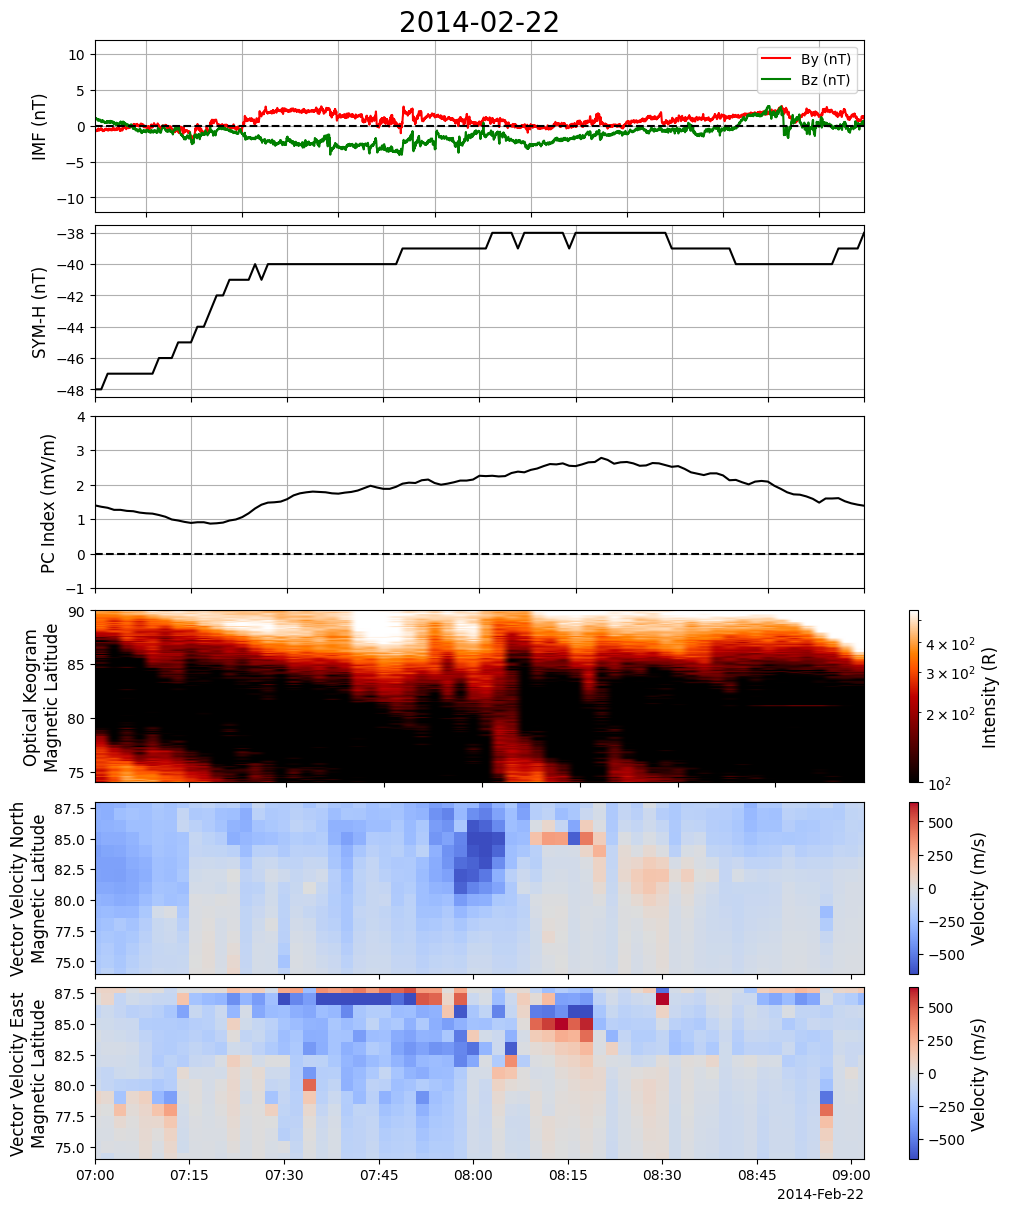

In [ ]:
plot(optical_keo_img, optical_times, vnorth, veast, radar_lat_array, radar_time, SYM_H, SYM_H_time.astype('datetime64[s]'), PC_index, B_vals, B_times)